# AssetOpsBench Dataset - Exploration & Analysis

**Source:** [ibm-research/AssetOpsBench](https://huggingface.co/datasets/ibm-research/AssetOpsBench)

AssetOpsBench is a benchmark for evaluating LLMs and Multi-Agent systems on industrial asset operations & maintenance tasks — covering IoT sensor data, failure mode analysis, time-series forecasting, and work order generation.

**6 subsets:** `scenarios`, `compressor`, `failure mode sensor mapping`, `hydrolic_pump`, `prognostics_and_health_management`, `rule_logic`

## 1. Download All Subsets

In [1]:
from datasets import load_dataset
import pandas as pd
from pathlib import Path

SUBSET_NAMES = [
    "scenarios",
    "compressor",
    "failure mode sensor mapping",
    "hydrolic_pump",
    "prognostics_and_health_management",
    "rule_logic",
]

# Local save directory
DATA_DIR = Path("data/assetOpsBench")
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Download all subsets, convert to DataFrames, and save as CSV
dfs = {}
for name in SUBSET_NAMES:
    ds = load_dataset("ibm-research/AssetOpsBench", name)
    dfs[name] = ds["train"].to_pandas()
    safe_name = name.replace(" ", "_")
    dfs[name].to_csv(DATA_DIR / f"{safe_name}.csv", index=False)
    print(f"✓ {name:>40s}  →  {len(dfs[name]):>4d} rows, {len(dfs[name].columns):>2d} columns  →  saved to {DATA_DIR}/{safe_name}.csv")

print(f"\nTotal rows across all subsets: {sum(len(df) for df in dfs.values())}")
print(f"Files saved in: {DATA_DIR.resolve()}")

/Users/alimurtazamerchant/Desktop/HPML/Project/AssetOpsBench/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓                                scenarios  →   152 rows,  9 columns  →  saved to data/assetOpsBench/scenarios.csv
✓                               compressor  →    15 rows, 11 columns  →  saved to data/assetOpsBench/compressor.csv
✓              failure mode sensor mapping  →    88 rows, 10 columns  →  saved to data/assetOpsBench/failure_mode_sensor_mapping.csv
✓                            hydrolic_pump  →    17 rows, 12 columns  →  saved to data/assetOpsBench/hydrolic_pump.csv
✓        prognostics_and_health_management  →    75 rows,  9 columns  →  saved to data/assetOpsBench/prognostics_and_health_management.csv
✓                               rule_logic  →   120 rows,  8 columns  →  saved to data/assetOpsBench/rule_logic.csv

Total rows across all subsets: 467
Files saved in: /Users/alimurtazamerchant/Desktop/HPML/Project/data/assetOpsBench


## 2. Schema Overview — Columns & Types per Subset

In [2]:
for name, df in dfs.items():
    print(f"\n{'='*60}")
    print(f"  {name}  ({len(df)} rows)")
    print(f"{'='*60}")
    print(df.dtypes.to_string())
    print(f"\nNull counts:\n{df.isnull().sum().to_string()}")


  scenarios  (152 rows)
id                     int64
type                     str
text                     str
category                 str
deterministic           bool
characteristic_form      str
group                    str
entity                   str
note                     str

Null counts:
id                     0
type                   0
text                   0
category               0
deterministic          0
characteristic_form    0
group                  0
entity                 0
note                   0

  compressor  (15 rows)
id                     int64
type                     str
entity                   str
group                    str
text                     str
hint                     str
category                 str
labels                   str
characteristic_form      str
failure_event            str
note                     str

Null counts:
id                     0
type                   0
entity                 0
group                  0
text             

## 3. Sample Rows from Each Subset

In [3]:
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", None)

for name, df in dfs.items():
    print(f"\n{'─'*80}")
    print(f"  {name} — first 3 rows")
    print(f"{'─'*80}")
    display(df.head(3))


────────────────────────────────────────────────────────────────────────────────
  scenarios — first 3 rows
────────────────────────────────────────────────────────────────────────────────


,id,type,text,category,deterministic,characteristic_form,group,entity,note
0,1,IoT,What IoT sites are available?,Knowledge Query,True,"The expected response should be the return value of all sites, either as text or as a reference to a file",retrospective,Site,Source: IoT data operations; Deterministic query with single correct answer; Category: Knowledge Query
1,2,IoT,Can you list the IoT sites?,Knowledge Query,True,"The expected response should be the return value of all sites, either as text or as a reference to a file",retrospective,Site,Source: IoT data operations; Deterministic query with single correct answer; Category: Knowledge Query
2,3,IoT,What assets can be found at the MAIN site?,Knowledge Query,True,The expected response should be the return value from querying the assets at the MAIN site. The response should be a...,retrospective,Site,Source: IoT data operations; Deterministic query with single correct answer; Category: Knowledge Query



────────────────────────────────────────────────────────────────────────────────
  compressor — first 3 rows
────────────────────────────────────────────────────────────────────────────────


,id,type,entity,group,text,hint,category,labels,characteristic_form,failure_event,note
0,1001,multiagent,compressor,Predictive Maintenance,"Consider asset mp_1. Based on the compressor sensor readings from April 10 to April 17, 2020, is there a risk of an ...",IoT Agent handles raw sensor data ingestion and cleaning; TSFM Agent is responsible for anomaly detection and predic...,7-Day Ahead Failure Prediction,"pre-failure, prediction, 7-day","The response should identify subtle trends or deviations across sensor streams indicating degradation (e.g., pressur...","Air Leak starting April 18, 2020",
1,1002,multiagent,compressor,Predictive Maintenance,"Consider asset mp_1. Looking at the compressor data collected on April 17, 2020, can we determine whether an air lea...",IoT Agent manages sensor data streams; TSFM Agent focuses on real-time anomaly detection; FMSR Agent narrows down fa...,24-Hour Imminent Failure Warning,"pre-failure, prediction, 24-hour","The response should detect rapid onset anomalies, such as spikes or correlated irregularities in pressure, motor cur...","Air Leak starting April 18, 2020",
2,1003,multiagent,compressor,Maintenance Evaluation,"Consider asset mp_1. Following the air leak failure on April 18 and subsequent maintenance conducted on April 19, 20...",IoT Agent compares pre- and post-maintenance sensor data; TSFM Agent looks for lingering anomalies; FMSR Agent asses...,Post-Maintenance Health Assessment,"post-maintenance, health-check","The response should effectively contrast sensor indicators before and after maintenance, identifying if anomalies pe...","Air Leak starting April 18, 2020",



────────────────────────────────────────────────────────────────────────────────
  failure mode sensor mapping — first 3 rows
────────────────────────────────────────────────────────────────────────────────


...

,id,type,text,hint,category,characteristic_form,failure_event,entity,deterministic,asset_component,labels,relevant_sensors
0,2001,multiagent,"For asset hp_1, using sensor data from the last 50 days leading up to and including 2023-01-28, can we detect that t...",IoT Agent collects multi-sensor data over the fixed window; TSFM Agent examines temporal feature shifts; FMSR Agent ...,Fixed-Window Condition Detection (50 days),"Detection should integrate pressure, flow, vibration, and temperature trends across dates 2022-12-10 to 2023-01-28. ...",Valve close to total failure at date 2023-01-28,hydrolic_pump,True,valve,"valve, fixed-window, pre-failure","PS1, PS2, PS3, PS4, PS5, PS6, FS1, FS2, VS1"
1,2002,multiagent,"For asset hp_1, using sensor data from the last 50 days leading up to and including 2024-03-13, can we detect the va...",IoT aggregates valve-related sensor streams over the 50-day window; TSFM identifies evolving valve anomalies; FMSR c...,Fixed-Window Condition Detection (50 days),"Detection is based on multi-day feature trends including pressure sensors PS1–PS6, flow sensors FS1/FS2, and vibrati...",Valve close to total failure at date 2024-03-13,hydrolic_pump,True,valve,"valve, fixed-window, pre-failure","PS1, PS2, PS3, PS4, PS5, PS6, FS1, FS2, VS1"
2,2003,multiagent,"For asset hp_1, analyzing the last 50 days leading up to and including 2026-05-14, can the sensor data reveal a wors...",Multi-sensor sequence analysis performed over 2026-03-26 to 2026-05-14; TSFM and FMSR Agents detect and validate val...,Fixed-Window Condition Detection (50 days),Consistent anomalies in valve-switching-related sensor signals detected over the last 50 days before 2026-05-14 enab...,Valve close to total failure at date 2026-05-14,hydrolic_pump,True,valve,"valve, fixed-window, pre-failure","PS1, PS2, PS3, PS4, PS5, PS6, FS1, FS2, VS1"



────────────────────────────────────────────────────────────────────────────────
  prognostics_and_health_management — first 3 rows
────────────────────────────────────────────────────────────────────────────────


,id,text,type,category,deterministic,characteristic_form,group,entity,note
0,pdm_rul_001,I am managing a fleet of aircraft engines and need to know which ones are running on fumes. Can you predict the rema...,phm,RUL Prediction,True,The aircraft engine maintenance prediction workflow requires executing seven critical tools in a specific sequence t...,phm,engine,
1,pdm_rul_002,We have got bearing vibration data from CWRU and I need to figure out which bearings are about to give out. Can you ...,phm,RUL Prediction,True,The characteristic form for this bearing failure prediction workflow establishes a comprehensive sequential process ...,phm,bearing,
2,pdm_rul_003,"The FEMTO dataset has bearings running under three different operational scenarios, and I suspect the RUL prediction...",phm,RUL Prediction,True,The characteristic form for this evaluation workflow requires a systematic approach to analyzing bearing failure pre...,phm,bearings,



────────────────────────────────────────────────────────────────────────────────
  rule_logic — first 3 rows
────────────────────────────────────────────────────────────────────────────────


,id,type,category,text,group,entity,deterministic,characteristic_form
0,1000,monitoring rule,Analysis & Inference,Please find anomalies for asset AHU HUR00118 between 2021-04-11T23:00:00.000Z and 2021-04-12T05:15:00.000Z according...,retrospective,AHU,True,The expected response should be either a json string containing a time interval where the anomaly is present or a po...
1,1001,monitoring rule,Analysis & Inference,Please find anomalies for asset AHU 1156 between 2019-03-19T18:30:00.000Z and 2019-03-19T23:15:00.000Z according to:...,retrospective,AHU,True,The expected response should be either a json string containing a time interval where the anomaly is present or a po...
2,1002,monitoring rule,Analysis & Inference,Please find anomalies for asset AHU Y15150AC between 2019-02-16T17:00:00.000Z and 2019-02-16T20:00:00.000Z according...,retrospective,AHU,True,The expected response should be either a json string containing a time interval where the anomaly is present or a po...


## 4. Distribution Analysis

### 4a. Task Type Distribution (across all subsets)

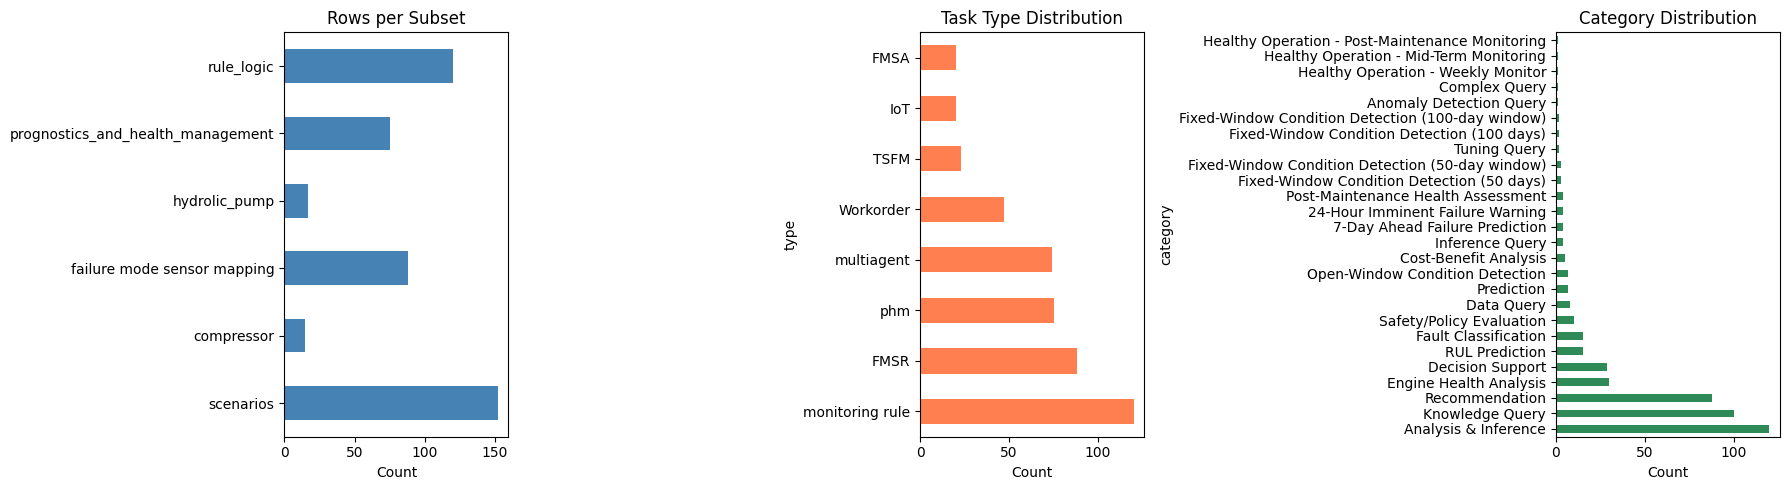

In [4]:
import matplotlib.pyplot as plt

# Combine all subsets with a source column
all_data = pd.concat(
    [df.assign(subset=name) for name, df in dfs.items()],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Rows per subset
dfs_counts = pd.Series({k: len(v) for k, v in dfs.items()})
dfs_counts.plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Rows per Subset")
axes[0].set_xlabel("Count")

# Type distribution
if "type" in all_data.columns:
    all_data["type"].value_counts().plot.barh(ax=axes[1], color="coral")
    axes[1].set_title("Task Type Distribution")
    axes[1].set_xlabel("Count")

# Category distribution
if "category" in all_data.columns:
    all_data["category"].value_counts().plot.barh(ax=axes[2], color="seagreen")
    axes[2].set_title("Category Distribution")
    axes[2].set_xlabel("Count")

plt.tight_layout()
plt.show()

### 4b. Entity & Deterministic Breakdown

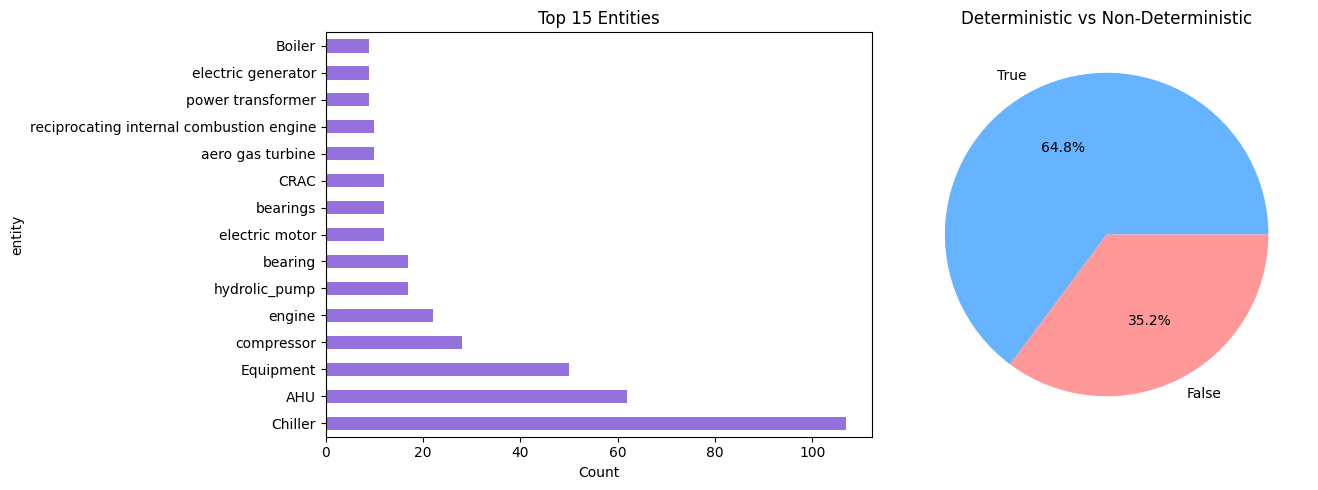

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Entity distribution
if "entity" in all_data.columns:
    all_data["entity"].value_counts().head(15).plot.barh(ax=axes[0], color="mediumpurple")
    axes[0].set_title("Top 15 Entities")
    axes[0].set_xlabel("Count")

# Deterministic vs non-deterministic
if "deterministic" in all_data.columns:
    all_data["deterministic"].value_counts().plot.pie(
        ax=axes[1], autopct="%1.1f%%", colors=["#66b3ff", "#ff9999"]
    )
    axes[1].set_title("Deterministic vs Non-Deterministic")
    axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### 4c. Type × Category Heatmap

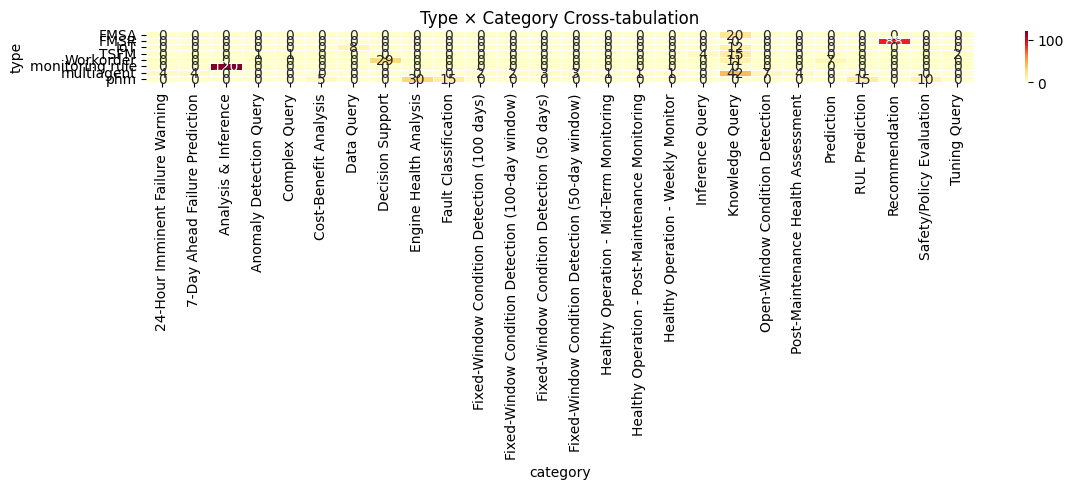

In [6]:
import seaborn as sns

if "type" in all_data.columns and "category" in all_data.columns:
    ct = pd.crosstab(all_data["type"], all_data["category"])
    plt.figure(figsize=(12, 5))
    sns.heatmap(ct, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5)
    plt.title("Type × Category Cross-tabulation")
    plt.tight_layout()
    plt.show()

## 5. Text Length Analysis

How long are the scenario/question texts?

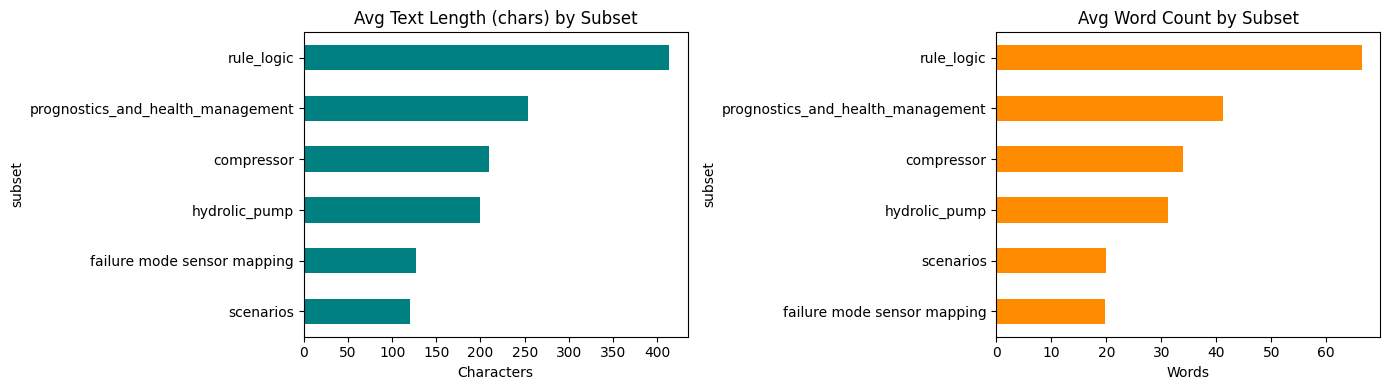


Overall text statistics:
       text_len  word_count
count     467.0       467.0
mean      224.2        36.1
std       175.5        28.9
min        27.0         5.0
25%       112.0        18.0
50%       165.0        25.0
75%       309.0        49.0
max      1272.0       215.0


In [7]:
all_data["text_len"] = all_data["text"].astype(str).str.len()
all_data["word_count"] = all_data["text"].astype(str).str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

all_data.groupby("subset")["text_len"].mean().sort_values().plot.barh(ax=axes[0], color="teal")
axes[0].set_title("Avg Text Length (chars) by Subset")
axes[0].set_xlabel("Characters")

all_data.groupby("subset")["word_count"].mean().sort_values().plot.barh(ax=axes[1], color="darkorange")
axes[1].set_title("Avg Word Count by Subset")
axes[1].set_xlabel("Words")

plt.tight_layout()
plt.show()

print("\nOverall text statistics:")
print(all_data[["text_len", "word_count"]].describe().round(1))

## 6. Unique Values Summary

Quick look at cardinality of key categorical columns across all subsets.

In [8]:
cat_cols = ["type", "category", "entity", "group", "characteristic_form"]
for col in cat_cols:
    if col in all_data.columns:
        vals = all_data[col].dropna().unique()
        print(f"\n{col} ({len(vals)} unique):")
        for v in sorted(vals):
            print(f"  - {v}")


type (8 unique):
  - FMSA
  - FMSR
  - IoT
  - TSFM
  - Workorder
  - monitoring rule
  - multiagent
  - phm

category (26 unique):
  - 24-Hour Imminent Failure Warning
  - 7-Day Ahead Failure Prediction
  - Analysis & Inference
  - Anomaly Detection Query
  - Complex Query
  - Cost-Benefit Analysis
  - Data Query
  - Decision Support
  - Engine Health Analysis
  - Fault Classification
  - Fixed-Window Condition Detection (100 days)
  - Fixed-Window Condition Detection (100-day window)
  - Fixed-Window Condition Detection (50 days)
  - Fixed-Window Condition Detection (50-day window)
  - Healthy Operation - Mid-Term Monitoring
  - Healthy Operation - Post-Maintenance Monitoring
  - Healthy Operation - Weekly Monitor
  - Inference Query
  - Knowledge Query
  - Open-Window Condition Detection
  - Post-Maintenance Health Assessment
  - Prediction
  - RUL Prediction
  - Recommendation
  - Safety/Policy Evaluation
  - Tuning Query

entity (32 unique):
  - 
  - AHU
  - Boiler
  - CRAC
  - C

## 7. Subset-specific Deep Dives

In [9]:
# Scenarios subset — the main benchmark scenarios
df_sc = dfs["scenarios"]
print("=== SCENARIOS ===")
print(f"\nType breakdown:")
print(df_sc["type"].value_counts().to_string())
print(f"\nCategory breakdown:")
print(df_sc["category"].value_counts().to_string())
print(f"\nEntity breakdown:")
print(df_sc["entity"].value_counts().to_string())
print(f"\nDeterministic: {df_sc['deterministic'].sum()} / {len(df_sc)}")

=== SCENARIOS ===

Type breakdown:
type
Workorder     47
multiagent    42
TSFM          23
IoT           20
FMSA          20

Category breakdown:
category
Knowledge Query            100
Decision Support            29
Data Query                   8
Prediction                   7
Inference Query              4
Tuning Query                 2
Anomaly Detection Query      1
Complex Query                1

Entity breakdown:
entity
Chiller        91
Equipment      50
AHU             6
Site            3
WindTurbine     2

Deterministic: 81 / 152


In [10]:
# Compressor & Hydraulic Pump — asset-specific fault diagnostics
for name in ["compressor", "hydrolic_pump"]:
    df = dfs[name]
    print(f"\n=== {name.upper()} ({len(df)} rows) ===")
    print(f"Columns: {list(df.columns)}")
    # Show unique failure events if present
    if "failure_event" in df.columns:
        print(f"\nFailure events ({df['failure_event'].nunique()} unique):")
        for fe in df["failure_event"].dropna().unique():
            print(f"  - {fe}")
    if "labels" in df.columns:
        print(f"\nLabels: {df['labels'].dropna().unique().tolist()}")


=== COMPRESSOR (15 rows) ===
Columns: ['id', 'type', 'entity', 'group', 'text', 'hint', 'category', 'labels', 'characteristic_form', 'failure_event', 'note']

Failure events (5 unique):
  - Air Leak starting April 18, 2020
  - Air Leak starting May 29, 2020
  - Air Leak starting June 5, 2020
  - Air Leak starting July 15, 2020
  - No failure - normal operation

Labels: ['pre-failure, prediction, 7-day', 'pre-failure, prediction, 24-hour', 'post-maintenance, health-check', 'normal, healthy, no-failure']

=== HYDROLIC_PUMP (17 rows) ===
Columns: ['id', 'type', 'text', 'hint', 'category', 'characteristic_form', 'failure_event', 'entity', 'deterministic', 'asset_component', 'labels', 'relevant_sensors']

Failure events (17 unique):
  - Valve close to total failure at date 2023-01-28
  - Valve close to total failure at date 2024-03-13
  - Valve close to total failure at date 2026-05-14
  - Severe pump leakage onset at date 2023-01-27
  - Severe pump leakage onset at day 2023-06-09
  - Seve

In [11]:
# PHM subset
df_phm = dfs["prognostics_and_health_management"]
print(f"=== PROGNOSTICS & HEALTH MANAGEMENT ({len(df_phm)} rows) ===")
print(f"\nCategory breakdown:")
print(df_phm["category"].value_counts().to_string())
print(f"\nGroup breakdown:")
print(df_phm["group"].value_counts().to_string())
print(f"\nSample questions:")
for q in df_phm["text"].head(5):
    print(f"  • {q[:150]}")

=== PROGNOSTICS & HEALTH MANAGEMENT (75 rows) ===

Category breakdown:
category
Engine Health Analysis      30
RUL Prediction              15
Fault Classification        15
Safety/Policy Evaluation    10
Cost-Benefit Analysis        5

Group breakdown:
group
phm    75

Sample questions:
  • I am managing a fleet of aircraft engines and need to know which ones are running on fumes. Can you predict the remaining useful life for all test eng
  • We have got bearing vibration data from CWRU and I need to figure out which bearings are about to give out. Can you predict how much life each test be
  • The FEMTO dataset has bearings running under three different operational scenarios, and I suspect the RUL predictions might vary by scenario. Can you 
  • The XJTU dataset has bearings with five different fault types, and I want to see if our RUL predictions are more accurate for certain fault types. Can
  • The IMS dataset has very high-frequency vibration data, and I am worried that units show

In [12]:
# Rule Logic subset
df_rl = dfs["rule_logic"]
print(f"=== RULE LOGIC ({len(df_rl)} rows) ===")
print(f"\nCategory breakdown:")
print(df_rl["category"].value_counts().to_string())
print(f"\nEntity breakdown:")
print(df_rl["entity"].value_counts().to_string())
print(f"\nSample rules:")
for q in df_rl["text"].head(5):
    print(f"  • {q[:150]}")

=== RULE LOGIC (120 rows) ===

Category breakdown:
category
Analysis & Inference    120

Entity breakdown:
entity
AHU              56
Chiller          16
CRAC             12
Boiler            9
HXU               9
Pump              9
Cooling Tower     6
                  3

Sample rules:
  • Please find anomalies for asset AHU HUR00118 between 2021-04-11T23:00:00.000Z and 2021-04-12T05:15:00.000Z according to: An anomaly is detected when t
  • Please find anomalies for asset AHU 1156 between 2019-03-19T18:30:00.000Z and 2019-03-19T23:15:00.000Z according to: An anomaly is detected when the A
  • Please find anomalies for asset AHU Y15150AC between 2019-02-16T17:00:00.000Z and 2019-02-16T20:00:00.000Z according to: An anomaly is detected when t
  • Please find anomalies for asset AHU 5044 between 2020-02-13T10:15:00.000Z and 2020-02-13T12:30:00.000Z according to: The condition has 6 parts. (1) Th
  • Please find anomalies for asset AHU D15150BH between 2020-06-27T11:00:00.000Z and 2020-

## 8. Column Overlap Across Subsets

Which columns are shared vs unique to each subset?

In [13]:
all_cols = sorted(set().union(*[set(df.columns) for df in dfs.values()]))
col_presence = pd.DataFrame(
    {name: {col: col in df.columns for col in all_cols} for name, df in dfs.items()}
)
col_presence.index.name = "column"

# Style: green = present, red = absent
styled = col_presence.style.map(lambda v: "background-color: #c6efce" if v else "background-color: #ffc7ce")
display(styled)

,scenarios,compressor,failure mode sensor mapping,hydrolic_pump,prognostics_and_health_management,rule_logic
column,,,,,,
asset_component,False,False,False,True,False,False
category,True,True,True,True,True,True
characteristic_form,True,True,True,True,True,True
deterministic,True,False,True,True,True,True
entity,True,True,True,True,True,True
failure_event,False,True,False,True,False,False
group,True,True,True,False,True,True
hint,False,True,False,True,False,False
id,True,True,True,True,True,True
